# Problem 1 - Data Cleaning

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sb

In [2]:
#Load the dataset
fdf = pd.read_excel("amazon_laptop_2023.xlsx")
fdf

,brand,model,screen_size,color,harddisk,cpu,ram,OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price
0,HP,EliteBook 840,14 Inches,Silver,256 GB,Core i5 6200U,16 GB,Windows 10 Pro,Anti Glare Coating,Integrated,NaN,NaN,4.0,"$1,000.00"
1,Dell,Inspiron 15 3530,15.6 Inches,Black,2 TB,Core i7 Family,64 GB,Windows 11 Home,NaN,Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,000.00"
2,Dell,Vostro 3510 Laptop,15.6 Inches,Black,1000 GB,Core i7,32 GB,Windows 10 Home,Wifi & Bluetooth,Integrated,NaN,NaN,NaN,"$1,000.99"
3,Dell,Inspiron 7420 2-in-1,14 Inches,"Grey, Gray, Platinum Silver",2000 GB,Core i5,64 GB,Windows 11 Pro,NaN,Integrated,Intel Integrated Graphics,NaN,NaN,"$1,001.11"
4,MSI,Prestige 14Evo A11MO-217,14 Inches,Gary,NaN,Core i7,32 GB,Windows 10,"Anti-glare,Thin Bezel",Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4441,Dell,Dell Latitude Rugged 5404,14 Inches,Black,256 GB,Core i7,8 GB,Windows 10 Pro,Backlit Keyboard,Integrated,NaN,NaN,4.3,NaN
4442,HP,HPS13,15 Inches,Grey,128 GB,Pentium Other,4 GB,Windows 11 S,HD Audio,Integrated,NaN,NaN,4.3,NaN
4443,Microsoft,Surface Laptop Go 2,12.4 Inches,Sage,256 GB,Intel Core i5-1135G7,8 GB,Windows 10 S,NaN,Integrated,Intel Iris,NaN,NaN,NaN
4444,dell,DELL Latitude 5300,13.3 Inches,NaN,512 GB,Core i5 8250U,16 GB,Windows 10 Pro,Speakers,Integrated,Intel Integrated Graphics,NaN,4.2,NaN


In [3]:
#Check the number of duplicate rows
fdf.duplicated().value_counts()

False    2628
True     1818
dtype: int64

In [4]:
#Remove the duplicate rows as they are redundant
fdf.drop_duplicates(inplace=True, ignore_index=True)
fdf

,brand,model,screen_size,color,harddisk,cpu,ram,OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price
0,HP,EliteBook 840,14 Inches,Silver,256 GB,Core i5 6200U,16 GB,Windows 10 Pro,Anti Glare Coating,Integrated,NaN,NaN,4.0,"$1,000.00"
1,Dell,Inspiron 15 3530,15.6 Inches,Black,2 TB,Core i7 Family,64 GB,Windows 11 Home,NaN,Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,000.00"
2,Dell,Vostro 3510 Laptop,15.6 Inches,Black,1000 GB,Core i7,32 GB,Windows 10 Home,Wifi & Bluetooth,Integrated,NaN,NaN,NaN,"$1,000.99"
3,Dell,Inspiron 7420 2-in-1,14 Inches,"Grey, Gray, Platinum Silver",2000 GB,Core i5,64 GB,Windows 11 Pro,NaN,Integrated,Intel Integrated Graphics,NaN,NaN,"$1,001.11"
4,MSI,Prestige 14Evo A11MO-217,14 Inches,Gary,NaN,Core i7,32 GB,Windows 10,"Anti-glare,Thin Bezel",Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2623,Dell,Dell Latitude Rugged 5404,14 Inches,Black,256 GB,Core i7,8 GB,Windows 10 Pro,Backlit Keyboard,Integrated,NaN,NaN,4.3,NaN
2624,HP,HPS13,15 Inches,Grey,128 GB,Pentium Other,4 GB,Windows 11 S,HD Audio,Integrated,NaN,NaN,4.3,NaN
2625,Microsoft,Surface Laptop Go 2,12.4 Inches,Sage,256 GB,Intel Core i5-1135G7,8 GB,Windows 10 S,NaN,Integrated,Intel Iris,NaN,NaN,NaN
2626,dell,DELL Latitude 5300,13.3 Inches,NaN,512 GB,Core i5 8250U,16 GB,Windows 10 Pro,Speakers,Integrated,Intel Integrated Graphics,NaN,4.2,NaN


In [5]:
#Remove all empty rows and columns
fdf.dropna(how="all", inplace=True)
fdf.dropna(axis=1, how="all", inplace=True)
fdf

,brand,model,screen_size,color,harddisk,cpu,ram,OS,special_features,graphics,graphics_coprocessor,cpu_speed,rating,price
0,HP,EliteBook 840,14 Inches,Silver,256 GB,Core i5 6200U,16 GB,Windows 10 Pro,Anti Glare Coating,Integrated,NaN,NaN,4.0,"$1,000.00"
1,Dell,Inspiron 15 3530,15.6 Inches,Black,2 TB,Core i7 Family,64 GB,Windows 11 Home,NaN,Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,000.00"
2,Dell,Vostro 3510 Laptop,15.6 Inches,Black,1000 GB,Core i7,32 GB,Windows 10 Home,Wifi & Bluetooth,Integrated,NaN,NaN,NaN,"$1,000.99"
3,Dell,Inspiron 7420 2-in-1,14 Inches,"Grey, Gray, Platinum Silver",2000 GB,Core i5,64 GB,Windows 11 Pro,NaN,Integrated,Intel Integrated Graphics,NaN,NaN,"$1,001.11"
4,MSI,Prestige 14Evo A11MO-217,14 Inches,Gary,NaN,Core i7,32 GB,Windows 10,"Anti-glare,Thin Bezel",Integrated,Intel Iris Xe Graphics,NaN,4.2,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2623,Dell,Dell Latitude Rugged 5404,14 Inches,Black,256 GB,Core i7,8 GB,Windows 10 Pro,Backlit Keyboard,Integrated,NaN,NaN,4.3,NaN
2624,HP,HPS13,15 Inches,Grey,128 GB,Pentium Other,4 GB,Windows 11 S,HD Audio,Integrated,NaN,NaN,4.3,NaN
2625,Microsoft,Surface Laptop Go 2,12.4 Inches,Sage,256 GB,Intel Core i5-1135G7,8 GB,Windows 10 S,NaN,Integrated,Intel Iris,NaN,NaN,NaN
2626,dell,DELL Latitude 5300,13.3 Inches,NaN,512 GB,Core i5 8250U,16 GB,Windows 10 Pro,Speakers,Integrated,Intel Integrated Graphics,NaN,4.2,NaN


In [6]:
fdf.describe()

,rating
count,1041.000000
mean,4.100000
std,0.813811
min,1.000000
25%,3.800000
50%,4.200000
75%,4.600000
max,5.000000


In [7]:
#Percent of each column that is empty
print((fdf.isna().sum() / fdf.shape[0])*100)
print(fdf.shape[0])

brand                    0.000000
model                    4.984779
screen_size              1.065449
color                   21.232877
harddisk                 6.849315
cpu                      3.767123
ram                      2.207002
OS                       0.989346
special_features        34.512938
graphics                 2.359209
graphics_coprocessor    60.426180
cpu_speed               87.442922
rating                  60.388128
price                    0.190259
dtype: float64
2628


In [8]:
#Drop the unusable columns
unused_columns = ['color', 'special_features', 'cpu_speed', 'rating']
df = fdf.drop(unused_columns, axis=1)
df.columns.to_list()

['brand',
 'model',
 'screen_size',
 'harddisk',
 'cpu',
 'ram',
 'OS',
 'graphics',
 'graphics_coprocessor',
 'price']

In [9]:
#Split the columns into categorical and numerical
features_cat = ['brand', 'model', 'cpu', 'OS', 'graphics', 'graphics_coprocessor']
features_num = ['screen_size', 'harddisk', 'ram', 'price']

In [10]:
#Fill missing values with relevant labels
df[features_cat] = df[features_cat].fillna('NA')
df[features_num] = df[features_num].fillna(np.nan)
df

,brand,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
0,HP,EliteBook 840,14 Inches,256 GB,Core i5 6200U,16 GB,Windows 10 Pro,Integrated,NA,"$1,000.00"
1,Dell,Inspiron 15 3530,15.6 Inches,2 TB,Core i7 Family,64 GB,Windows 11 Home,Integrated,Intel Iris Xe Graphics,"$1,000.00"
2,Dell,Vostro 3510 Laptop,15.6 Inches,1000 GB,Core i7,32 GB,Windows 10 Home,Integrated,NA,"$1,000.99"
3,Dell,Inspiron 7420 2-in-1,14 Inches,2000 GB,Core i5,64 GB,Windows 11 Pro,Integrated,Intel Integrated Graphics,"$1,001.11"
4,MSI,Prestige 14Evo A11MO-217,14 Inches,NaN,Core i7,32 GB,Windows 10,Integrated,Intel Iris Xe Graphics,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...
2623,Dell,Dell Latitude Rugged 5404,14 Inches,256 GB,Core i7,8 GB,Windows 10 Pro,Integrated,NA,NaN
2624,HP,HPS13,15 Inches,128 GB,Pentium Other,4 GB,Windows 11 S,Integrated,NA,NaN
2625,Microsoft,Surface Laptop Go 2,12.4 Inches,256 GB,Intel Core i5-1135G7,8 GB,Windows 10 S,Integrated,Intel Iris,NaN
2626,dell,DELL Latitude 5300,13.3 Inches,512 GB,Core i5 8250U,16 GB,Windows 10 Pro,Integrated,Intel Integrated Graphics,NaN


In [11]:
#Clean all string values to make them consisent
def string_clean(val):
    string = str(val)
    if string != 'NA':
        string = string.strip().lower()
    return string

for col in features_cat:
    df[col] = df[col].apply(string_clean)
df

,brand,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
0,hp,elitebook 840,14 Inches,256 GB,core i5 6200u,16 GB,windows 10 pro,integrated,NA,"$1,000.00"
1,dell,inspiron 15 3530,15.6 Inches,2 TB,core i7 family,64 GB,windows 11 home,integrated,intel iris xe graphics,"$1,000.00"
2,dell,vostro 3510 laptop,15.6 Inches,1000 GB,core i7,32 GB,windows 10 home,integrated,NA,"$1,000.99"
3,dell,inspiron 7420 2-in-1,14 Inches,2000 GB,core i5,64 GB,windows 11 pro,integrated,intel integrated graphics,"$1,001.11"
4,msi,prestige 14evo a11mo-217,14 Inches,NaN,core i7,32 GB,windows 10,integrated,intel iris xe graphics,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...
2623,dell,dell latitude rugged 5404,14 Inches,256 GB,core i7,8 GB,windows 10 pro,integrated,NA,NaN
2624,hp,hps13,15 Inches,128 GB,pentium other,4 GB,windows 11 s,integrated,NA,NaN
2625,microsoft,surface laptop go 2,12.4 Inches,256 GB,intel core i5-1135g7,8 GB,windows 10 s,integrated,intel iris,NaN
2626,dell,dell latitude 5300,13.3 Inches,512 GB,core i5 8250u,16 GB,windows 10 pro,integrated,intel integrated graphics,NaN


In [12]:
#Function to automatically group values that occur less than a specified minimum as 'other'
def reduce_levels(feat_check, minimum):
    val_counts = df[feat_check].value_counts()
    inds = list(val_counts[val_counts.values <= minimum].index)
    if 'NA' in inds:
        inds.remove('NA')
    for ind in inds:
        df[feat_check].loc[df[feat_check] == ind] = 'other'
    print(df[feat_check].value_counts())

#Function to print the counts of values in a column with a specific substring and under a certain threshold
def print_vals(feature, string = '', threshold = 4000):
    val_counts = df[feature].loc[df[feature].str.contains(string, na=False)].value_counts()
    print(val_counts[val_counts.values <= threshold])
    print(val_counts.index.to_list())

In [13]:
#Clean the brand column
feature = 'brand'
print_vals(feature)

dell                             1498
lenovo                            311
hp                                256
asus                              162
acer                              115
msi                                85
lg                                 37
apple                              28
samsung                            23
microsoft                          15
alienware                          14
panasonic                          12
gigabyte                           11
toughbook                          11
rokc                                8
razer                               6
latitude                            3
luqeeg                              3
shoxlab                             2
gateway                             2
quality refurbished computers       2
iview                               2
mac                                 1
ctl                                 1
mytrix                              1
best notebooks                      1
awow        

In [14]:
#Clean the model column
feature = 'model'
print_vals(feature)

NA                       131
inspiron 3511 laptop      87
latitude 5520 laptop      85
latitude 3520 laptop      60
latitude                  42
                        ... 
asus rog zephyrus          1
t420                       1
asus                       1
acer 315                   1
hp prodesk 400 g3-sff      1
Name: model, Length: 1059, dtype: int64
['NA', 'inspiron 3511 laptop', 'latitude 5520 laptop', 'latitude 3520 laptop', 'latitude', 'dell latitude', 'latitude 5420 laptop', 'alienware m18 laptop', 'lenovo thinkpad', 'xps 9530 laptop', 'latitude 3420 laptop', 'xps 9320 laptop', 'vostro 3510 laptop', 'vostro 7620 laptop', 'latitude 7420 laptop', 'inspiron', 'precision 7770 laptop', 'latitude 5530 laptop', 'latitude 5320 laptop', 'precision 3000', 'lenovo ideapad', 'latitude 5000', 'alienware x17 r2 laptop', 'latitude 7000', 'xps 9510 laptop', 'xps 9520 laptop', 'latitude 7320 laptop', 'latitude 7440 laptop', 'latitude 5440 laptop', 'precision 7780 laptop', 'dell inspiron', 'x

In [15]:
#Combine the brand and model columns
df[feature].loc[df[feature] != 'NA'] = df['brand'] + ' ' + df[feature].loc[df[feature] != 'NA']
df[feature].loc[df[feature] == 'NA'] = df['brand']
df[feature]

0                     hp elitebook 840
1                dell inspiron 15 3530
2              dell vostro 3510 laptop
3            dell inspiron 7420 2-in-1
4         msi prestige 14evo a11mo-217
                     ...              
2623    dell dell latitude rugged 5404
2624                          hp hps13
2625     microsoft surface laptop go 2
2626           dell dell latitude 5300
2627          hp hp prodesk 400 g3-sff
Name: model, Length: 2628, dtype: object

In [16]:
#Clean the new combined column to remove duplicate brand names
for i in df[feature]:
    string = str(i)
    words = string.split(' ')
    if len(words) == 1:
        continue
    if words[0] == words[1]:
        del words[0]
        df[feature].loc[df[feature] == i] = ' '.join(words)
        
df[feature] = df[feature].apply(string_clean)
df.drop('brand', axis=1, inplace=True)
features_cat.remove('brand')
df[feature]

0                    hp elitebook 840
1               dell inspiron 15 3530
2             dell vostro 3510 laptop
3           dell inspiron 7420 2-in-1
4        msi prestige 14evo a11mo-217
                    ...              
2623        dell latitude rugged 5404
2624                         hp hps13
2625    microsoft surface laptop go 2
2626               dell latitude 5300
2627            hp prodesk 400 g3-sff
Name: model, Length: 2628, dtype: object

In [17]:
#Clean the cpu column
feature = 'cpu'
print_vals(feature)

core i7              791
core i5              561
core i7 family       166
core i9              136
NA                    99
                    ... 
ryzen 7 2700u          1
amd ryzen 7 5800h      1
core i7 7500u          1
intel core 2 quad      1
core i5 2.3 ghz        1
Name: cpu, Length: 142, dtype: int64
['core i7', 'core i5', 'core i7 family', 'core i9', 'NA', 'intel core i7', 'celeron', 'amd ryzen 7', 'core i5 family', 'core i3', 'intel core i5', 'ryzen 7', 'intel core i9', 'ryzen 5', '8032', 'intel core i5-1135g7', 'celeron n', 'celeron n4020', 'amd r series', 'intel core i3', 'pentium', 'core i3 family', 'amd a series', 'corei7-10750h', 'unknown', 'ryzen 9', 'mediatek mt8183', 'apple m1', 'celeron n4000', 'intel mobile cpu', '1.2ghz cortex a8 processor', 'athlon', 'core i7 11800h', 'celeron n3350', 'intel core i7-1165g7', 'core i3-1005g1', 'ryzen 7 5800h', 'core i5-10210u', 'core i7-1065g7', 'core i3 1115g4', 'intel core i5 1145g7', 'celeron n3450', 'others', 'ryzen 3 3250u',

In [18]:
#Group common values and correct synonymous values
df[feature].loc[df[feature] == 'unknown'] = 'NA'

values = [3, 5, 7, 9]
for value in values:
    df[feature].loc[df[feature].str.contains(f'core i{value}', na=False)] = f'core i{value}'
    df[feature].loc[df[feature].str.contains(f'corei{value}', na=False)] = f'core i{value}'
    df[feature].loc[df[feature].str.contains(f'ryzen {value}', na=False)] = f'ryzen {value}'

df[feature].loc[df[feature].str.contains('pentium', na=False)] = 'pentium'
df[feature].loc[df[feature].str.contains('celeron', na=False)] = 'celeron'
df[feature].loc[df[feature].str.contains('cortex', na=False)] = 'arm cortex'
df[feature].loc[df[feature].str.contains('apple', na=False)] = 'apple'
df[feature].loc[((df[feature].str.contains('core', na=False)) & (~df[feature].str.contains('core i', na=False)))] = 'core other'

df[feature].loc[df[feature] == 'a-series'] = 'amd a series'
df[feature].loc[df[feature] == 'amd a4'] = 'amd a series'
df[feature].loc[df[feature] == 'a10-7700k'] = 'amd a series'

print_vals(feature)

core i7                1098
core i5                 716
core i9                 175
celeron                 121
ryzen 7                 113
NA                      109
core i3                  89
ryzen 5                  40
pentium                  21
8032                     18
amd a series             17
amd r series             15
core other               13
ryzen 9                  12
ryzen 3                  12
apple                    10
mediatek mt8183           9
arm cortex                8
intel mobile cpu          6
athlon                    5
others                    4
mediatek_mt8127           3
intel atom                3
snapdragon                3
intel xeon                2
athlon silver 3050u       2
68000                     1
atom z8350                1
arm 7100                  1
mediatek helio p60t       1
Name: cpu, dtype: int64
['core i7', 'core i5', 'core i9', 'celeron', 'ryzen 7', 'NA', 'core i3', 'ryzen 5', 'pentium', '8032', 'amd a series', 'amd r series', '

In [19]:
#Group occasionally occurring values
reduce_levels(feature, 9)

core i7         1098
core i5          716
core i9          175
celeron          121
ryzen 7          113
NA               109
core i3           89
other             49
ryzen 5           40
pentium           21
8032              18
amd a series      17
amd r series      15
core other        13
ryzen 3           12
ryzen 9           12
apple             10
Name: cpu, dtype: int64


In [20]:
#Clean the os column
feature = 'OS'
print_vals(feature)

windows 11 pro                                                              633
windows 11 home                                                             567
windows 10 pro                                                              439
windows 10 home                                                             424
windows 10                                                                  139
windows 11                                                                  124
chrome os                                                                   120
NA                                                                           26
mac os                                                                       19
windows 7 professional                                                       15
windows 10 s                                                                 14
windows 11 s                                                                 14
windows 7                               

In [21]:
#Group common values and correct synonymous values
df[feature].loc[df[feature] == 'unknown'] = 'NA'
df[feature].loc[df[feature] == 'no'] = 'NA'
df[feature].loc[df[feature] == 'pc'] = 'NA'

df[feature].loc[df[feature] == 'windows 7 pro + 10 pro'] = 'windows 10 pro'
df[feature].loc[df[feature] == 'windows 10 64 bit-multi-language supports english/spanish/french'] = 'windows 10'
df[feature].loc[df[feature] == 'windows 10 s, windows 10'] = 'windows 10 s'
df[feature].loc[df[feature] == 'win 10 multi-language /free upgrade to win 11'] = 'windows 10'
df[feature].loc[df[feature] == 'mac os x 10.0 cheetah'] = 'mac os'
df[feature].loc[df[feature] == 'win 11 multi-home'] = 'windows 11 home'
df[feature].loc[df[feature] == 'windows 7 home'] = 'windows 7'
df[feature].loc[df[feature] == 'windows 11 home s'] = 'windows 11 s'
df[feature].loc[df[feature] == 'windows 11 home in s mode'] = 'windows 11 s'

df[feature].loc[df[feature].str.contains('windows 8', na=False)] = 'windows 8'
df[feature].loc[df[feature].str.contains('macos', na=False)] = 'mac os'

values = [7, 8, 10, 11]
for value in values:
        df[feature].loc[df[feature].str.contains(f'windows {value} pro', na=False)] = f'windows {value} pro'
        df[feature].loc[df[feature].str.contains(f'win {value} pro', na=False)] = f'windows {value} pro'
        df[feature].loc[df[feature].str.contains(f'windows {value} home', na=False)] = f'windows {value} home'

print_vals(feature)

windows 11 pro     635
windows 11 home    568
windows 10 pro     471
windows 10 home    427
windows 10         142
windows 11         124
chrome os          120
mac os              30
NA                  29
windows 11 s        17
windows 7 pro       16
windows 10 s        15
windows 7           13
windows 8           11
windows              7
windows pro          1
linux                1
hp thinpro           1
Name: OS, dtype: int64
['windows 11 pro', 'windows 11 home', 'windows 10 pro', 'windows 10 home', 'windows 10', 'windows 11', 'chrome os', 'mac os', 'NA', 'windows 11 s', 'windows 7 pro', 'windows 10 s', 'windows 7', 'windows 8', 'windows', 'windows pro', 'linux', 'hp thinpro']


In [22]:
#Group occasionally occurring values
reduce_levels(feature, 2)

windows 11 pro     635
windows 11 home    568
windows 10 pro     471
windows 10 home    427
windows 10         142
windows 11         124
chrome os          120
mac os              30
NA                  29
windows 11 s        17
windows 7 pro       16
windows 10 s        15
windows 7           13
windows 8           11
windows              7
other                3
Name: OS, dtype: int64


In [23]:
#Clean the graphics column
feature = 'graphics'
print_vals(feature)

integrated                              1639
dedicated                                447
iris xe graphics                          85
NA                                        62
nvidia geforce rtx 4070                   27
                                        ... 
geforce rtx 3070 ti,iris xe graphics       1
gt2 graphics                               1
rtx 4080                                   1
rtx 2060                                   1
nvidia geforce gtx 1650 4gb                1
Name: graphics, Length: 110, dtype: int64
['integrated', 'dedicated', 'iris xe graphics', 'NA', 'nvidia geforce rtx 4070', 'uhd graphics', 'nvidia geforce rtx 3050 ti', 'integrated, dedicated', 'radeon graphics', 'nvidia rtx a3000', 'nvidia geforce rtx 4090', 'nvidia geforce rtx 4060', 'nvidia geforce rtx 3050', 'nvidia geforce rtx 4050', 'nvidia geforce rtx a500', 'nvidia t1200', 'nvidia rtx a2000', 't550', 'nvidia rtx a1000', 'nvidia geforce rtx 3060', 'rtx a1000', 'rtx a2000', 'nvidia quadro rtx 3

In [24]:
#Group common values and correct synonymous values
values = [4080, 4070, 4060, 4050, 3080, 3070, 3060, 3050, 2070, 2060, 2050]
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia geforce rtx {value}'

values = ['a500', 'a1000', 'a2000', 'a3000', '3500 ada']
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia rtx {value}'

values = [3070, 2060, 2050]
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx{value}', na=False)] = f'nvidia geforce rtx {value}'

values = [1200, 2000, 500, 550, 600]
for value in values:
    df[feature].loc[df[feature].str.contains(f't{value}', na=False)] = f'nvidia t{value}'

df[feature].loc[df[feature].str.contains('gtx 1650', na=False)] = 'nvidia geforce gtx 1650'
df[feature].loc[df[feature].str.contains('iris', na=False)] = 'iris xe graphics'
df[feature].loc[df[feature].str.contains('nvidia rtx a', na=False)] = 'nvidia rtx a series'
df[feature].loc[df[feature].str.contains('nvidia t', na=False)] = 'nvidia t series'
df[feature].loc[df[feature].str.contains('quadro', na=False)] = 'nvidia quadro'
df[feature].loc[df[feature].str.contains('ada', na=False)] = 'nvidia rtx ada series'
df[feature].loc[df[feature].str.contains('uhd', na=False)] = 'uhd graphics'
df[feature].loc[df[feature].str.contains('mx', na=False)] = 'nvidia geforce mx series'
df[feature].loc[df[feature].str.contains('rtx 2', na=False)] = 'nvidia geforce rtx 20 series'
df[feature].loc[df[feature].str.contains('radeon', na=False)] = 'radeon graphics'
df[feature].loc[df[feature].str.contains('shared', na=False)] = 'integrated'

df[feature].loc[((df[feature].str.contains('hd graphics', na=False)) & (~df[feature].str.contains('uhd graphics', na=False)))] = 'intel hd graphics'

df[feature].loc[df[feature] == 'nvidiaâ® geforce rtxâ„¢ 4060'] = 'nvidia geforce rtx 4060'
df[feature].loc[df[feature] == 'intel xe'] = 'iris xe graphics'

print_vals(feature)

integrated                      1641
dedicated                        447
iris xe graphics                  95
nvidia rtx a series               68
NA                                62
nvidia geforce rtx 3050           41
radeon graphics                   36
uhd graphics                      31
nvidia geforce rtx 4070           30
nvidia t series                   29
integrated, dedicated             22
nvidia geforce rtx 4090           15
nvidia geforce rtx 4060           14
nvidia geforce rtx 3070           13
nvidia geforce rtx 4050           11
nvidia geforce rtx 3060           11
nvidia geforce rtx 20 series      10
nvidia geforce rtx 3080           10
nvidia geforce mx series           7
nvidia quadro                      6
nvidia geforce gtx 1650            6
nvidia rtx ada series              6
nvidia geforce rtx 4080            5
intel hd graphics                  3
amd integrated graphics            3
intel arc a370m                    2
qn20-m1-r                          2
g

In [25]:
#Clean the graphics column
feature = 'graphics_coprocessor'
print_vals(feature)

NA                                      1588
intel iris xe graphics                   142
intel integrated graphics                102
intel uhd graphics                        89
intel                                     42
                                        ... 
mediatek                                   1
intel hd 5500                              1
integrated intelâ® uhd 600 graphics        1
nvidia geforce rtx 3050 ti 4gb gddr6       1
nvidia geforce gtx 965m                    1
Name: graphics_coprocessor, Length: 206, dtype: int64
['NA', 'intel iris xe graphics', 'intel integrated graphics', 'intel uhd graphics', 'intel', 'amd radeon graphics', 'intel uhd graphics 620', 'nvidia geforce rtx 3060', 'nvidia geforce rtx 4070', 'nvidia geforce rtx 3050 ti', 'intel hd graphics 520', 'integrated graphics', 'nvidia geforce rtx 3050', 'nvidia geforce rtx 4060', 'intel hd graphics 400', 'intel iris', 'intel uhd graphics 600', 'nvidia geforce rtx 3080', 'intel hd graphics 620', 'nvidi

In [26]:
#Group common values and correct synonymous values
values = [4080, 4070, 4060, 4050, 3080, 3070, 3060, 3050, 2070, 2060, 2050]
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia geforce rtx {value}'

values = ['a500', 'a1000', 'a2000', 'a3000', '3500 ada']
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia rtx {value}'

values = [3070, 2060, 2050]
for value in values:
    df[feature].loc[df[feature].str.contains(f'rtx{value}', na=False)] = f'nvidia geforce rtx {value}'

values = [1200, 2000, 500, 550, 600]
for value in values:
    df[feature].loc[df[feature].str.contains(f't{value}', na=False)] = f'nvidia t{value}'

df[feature].loc[df[feature].str.contains('intel hd', na=False)] = 'intel hd graphics'
df[feature].loc[df[feature].str.contains('nvidia rtx a', na=False)] = 'nvidia rtx a series'
df[feature].loc[df[feature].str.contains('quadro', na=False)] = 'nvidia quadro'
df[feature].loc[df[feature].str.contains('nvidia t', na=False)] = 'nvidia t series'
df[feature].loc[df[feature].str.contains('rtx 2', na=False)] = 'nvidia geforce rtx 20 series'
df[feature].loc[df[feature].str.contains('gtx', na=False)] = 'nvidia geforce gtx'
df[feature].loc[df[feature].str.contains('mx', na=False)] = 'nvidia geforce mx series'
df[feature].loc[df[feature].str.contains('radeon', na=False)] = 'radeon graphics'
df[feature].loc[df[feature].str.contains('iris', na=False)] = 'iris xe graphics'
df[feature].loc[df[feature].str.contains('uhd', na=False)] = 'uhd graphics'
df[feature].loc[(df[feature].str.contains('intel', na=False)) & (df[feature].str.contains('integrated', na=False)) & (df[feature].str.contains('graphic', na=False))] = 'intel integrated graphics'

df[feature].loc[df[feature] == 'nvidia â® geforce rtxâ„¢ 2060'] = 'nvidia geforce rtx 20 series'
df[feature].loc[df[feature] == 'nvidia â® rtxâ„¢ a4500, 16 gb gddr6'] = 'nvidia rtx a series'
df[feature].loc[df[feature] == 'nvidia â® geforce rtxâ„¢ 4050'] = 'nvidia geforce rtx 4050'
df[feature].loc[df[feature] == 'nvidia rtx 3000 6gb gddr6'] = 'nvidia quadro'
df[feature].loc[df[feature] == 'nvidia rtx 5000 16gb gddr6'] = 'nvidia quadro'
df[feature].loc[df[feature] == 'nvidia rtx3050'] = 'nvidia geforce rtx 3050'
df[feature].loc[df[feature] == 'nvidia geforce rtx a4500'] = 'nvidia rtx a series'
df[feature].loc[df[feature] == 'nvidia geforcer a3000'] = 'nvidia rtx a series'
df[feature].loc[df[feature] == 'nvidia geforce 3050'] = 'nvidia geforce rtx 3050'

remove = ['inter core i7-8650u', 'amd athlon silver', 'hd 620 graphics', 'm1 pro', 'intel celeron']
for i in remove:
    df['graphics_coprocessor'].loc[df['graphics_coprocessor'] == i] = 'NA'

print_vals(feature)

NA                                     1593
iris xe graphics                        167
uhd graphics                            145
intel hd graphics                       108
intel integrated graphics               107
radeon graphics                          90
nvidia geforce rtx 3050                  46
nvidia rtx a series                      45
intel                                    42
nvidia geforce gtx                       33
nvidia geforce rtx 3060                  25
nvidia geforce rtx 3080                  24
nvidia geforce rtx 4070                  23
nvidia geforce rtx 20 series             21
integrated graphics                      20
nvidia geforce rtx 3070                  20
nvidia geforce rtx 4060                  17
nvidia quadro                            14
nvidia t series                          10
nvidia geforce mx series                  9
nvidia geforce rtx 4080                   9
amd integrated graphics                   8
nvidia geforce rtx 4050         

In [27]:
df['graphics'].value_counts()

integrated                      1641
dedicated                        447
iris xe graphics                  95
nvidia rtx a series               68
NA                                62
nvidia geforce rtx 3050           41
radeon graphics                   36
uhd graphics                      31
nvidia geforce rtx 4070           30
nvidia t series                   29
integrated, dedicated             22
nvidia geforce rtx 4090           15
nvidia geforce rtx 4060           14
nvidia geforce rtx 3070           13
nvidia geforce rtx 4050           11
nvidia geforce rtx 3060           11
nvidia geforce rtx 20 series      10
nvidia geforce rtx 3080           10
nvidia geforce mx series           7
nvidia quadro                      6
nvidia geforce gtx 1650            6
nvidia rtx ada series              6
nvidia geforce rtx 4080            5
intel hd graphics                  3
amd integrated graphics            3
intel arc a370m                    2
qn20-m1-r                          2
g

In [28]:
#Label graphics processors as either integrated or dedicated
integrated = ['iris xe graphics', 'uhd graphics', 'radeon graphics', 'amd integrated graphics', 'intel hd graphics']
dedicated = df['graphics'].loc[df['graphics'].str.startswith('nvidia')].value_counts().index.to_list()
dedicated.append('intel arc a370m')
dedicated

['nvidia rtx a series',
 'nvidia geforce rtx 3050',
 'nvidia geforce rtx 4070',
 'nvidia t series',
 'nvidia geforce rtx 4090',
 'nvidia geforce rtx 4060',
 'nvidia geforce rtx 3070',
 'nvidia geforce rtx 3060',
 'nvidia geforce rtx 4050',
 'nvidia geforce rtx 20 series',
 'nvidia geforce rtx 3080',
 'nvidia geforce mx series',
 'nvidia quadro',
 'nvidia geforce gtx 1650',
 'nvidia rtx ada series',
 'nvidia geforce rtx 4080',
 'intel arc a370m']

In [29]:
for i in integrated:
    df['graphics_coprocessor'].loc[df['graphics'] == i] = i
    df['graphics'].loc[df['graphics'] == i] = 'integrated'

for i in dedicated:
    df['graphics_coprocessor'].loc[df['graphics'] == i] = i
    df['graphics'].loc[df['graphics'] == i] = 'dedicated'

print(df['graphics'].value_counts())
print(df['graphics_coprocessor'].value_counts())

integrated               1809
dedicated                 731
NA                         62
integrated, dedicated      22
qn20-m1-r                   2
gt2 graphics                1
adreno 618                  1
Name: graphics, dtype: int64
NA                                     1278
iris xe graphics                        216
uhd graphics                            152
intel hd graphics                       107
intel integrated graphics               107
radeon graphics                         102
nvidia rtx a series                      99
nvidia geforce rtx 3050                  85
nvidia geforce rtx 4070                  51
intel                                    42
nvidia geforce rtx 3060                  36
nvidia t series                          34
nvidia geforce gtx                       32
nvidia geforce rtx 3080                  31
nvidia geforce rtx 4060                  30
nvidia geforce rtx 20 series             29
nvidia geforce rtx 3070                  29
integrated gr

In [30]:
#Transfer integrated values to the graphics column
#References for this information outlined in the references section of the report
integrated = ['hd integrated graphics', 'intergrated', 'integrated card', 'integrated', 'integrated_graphics', 'integrated graphics', 'integreted']

for i in integrated:
    df['graphics'].loc[df['graphics_coprocessor'] == i] = 'integrated'
    df['graphics_coprocessor'].loc[df['graphics_coprocessor'] == i] = 'NA'

In [31]:
#Transfer unknown values
val_counts = df['graphics'].value_counts()
inds = list(val_counts[val_counts.values <= 5].index)
if 'NA' in inds:
    inds.remove('NA')
for ind in inds:
    df['graphics_coprocessor'].loc[df['graphics'] == ind] = ind
    df['graphics'].loc[df['graphics'] == ind] = 'NA'

print(df['graphics'].value_counts())
print(df['graphics_coprocessor'].value_counts())
print(df['graphics_coprocessor'].value_counts().index.to_list())

integrated               1810
dedicated                 731
NA                         66
integrated, dedicated      21
Name: graphics, dtype: int64
NA                                     1304
iris xe graphics                        216
uhd graphics                            152
intel integrated graphics               107
intel hd graphics                       107
radeon graphics                         102
nvidia rtx a series                      99
nvidia geforce rtx 3050                  85
nvidia geforce rtx 4070                  51
intel                                    42
nvidia geforce rtx 3060                  36
nvidia t series                          34
nvidia geforce gtx                       32
nvidia geforce rtx 3080                  31
nvidia geforce rtx 4060                  30
nvidia geforce rtx 20 series             29
nvidia geforce rtx 3070                  29
nvidia geforce rtx 4050                  19
nvidia quadro                            19
nvidia geforce 

In [32]:
#References for this information outlined in the references section of the report
integrated = ['iris xe graphics', 'uhd graphics', 'radeon graphics', 'amd integrated graphics', 'intel hd graphics', 'intel integrated graphics', 'mediatek integrated graphics', 'mediatek integrated', 'apple integrated graphics']
dedicated = df['graphics_coprocessor'].loc[df['graphics_coprocessor'].str.startswith('nvidia')].value_counts().index.to_list()
dedicated.append('intel arc a370m')
dedicated

['nvidia rtx a series',
 'nvidia geforce rtx 3050',
 'nvidia geforce rtx 4070',
 'nvidia geforce rtx 3060',
 'nvidia t series',
 'nvidia geforce gtx',
 'nvidia geforce rtx 3080',
 'nvidia geforce rtx 4060',
 'nvidia geforce rtx 20 series',
 'nvidia geforce rtx 3070',
 'nvidia geforce rtx 4050',
 'nvidia quadro',
 'nvidia geforce rtx 4090',
 'nvidia geforce mx series',
 'nvidia geforce rtx 4080',
 'nvidia geforce gtx 1650',
 'nvidia rtx ada series',
 'nvidia',
 'nvidia geforce rtx',
 'nvidia geforce gt 720m',
 'nvidia geforce',
 'nvidia â®',
 'nvidia geforce rtx 4000',
 'intel arc a370m']

In [33]:
#Assign either integrated or dedicated for each graphics coprocessor
for i in integrated:
    df['graphics'].loc[df['graphics_coprocessor'] == i] = 'integrated'

for i in dedicated:
    df['graphics'].loc[df['graphics_coprocessor'] == i] = 'dedicated'

print(df['graphics'].value_counts())
print(df['graphics_coprocessor'].value_counts())

integrated               1806
dedicated                 763
NA                         51
integrated, dedicated       8
Name: graphics, dtype: int64
NA                                     1304
iris xe graphics                        216
uhd graphics                            152
intel integrated graphics               107
intel hd graphics                       107
radeon graphics                         102
nvidia rtx a series                      99
nvidia geforce rtx 3050                  85
nvidia geforce rtx 4070                  51
intel                                    42
nvidia geforce rtx 3060                  36
nvidia t series                          34
nvidia geforce gtx                       32
nvidia geforce rtx 3080                  31
nvidia geforce rtx 4060                  30
nvidia geforce rtx 20 series             29
nvidia geforce rtx 3070                  29
nvidia geforce rtx 4050                  19
nvidia quadro                            19
nvidia geforce 

In [34]:
#Group occasionally occurring values
reduce_levels(feature, 5)

NA                              1304
iris xe graphics                 216
uhd graphics                     152
intel hd graphics                107
intel integrated graphics        107
radeon graphics                  102
nvidia rtx a series               99
nvidia geforce rtx 3050           85
nvidia geforce rtx 4070           51
intel                             42
nvidia geforce rtx 3060           36
other                             35
nvidia t series                   34
nvidia geforce gtx                32
nvidia geforce rtx 3080           31
nvidia geforce rtx 4060           30
nvidia geforce rtx 20 series      29
nvidia geforce rtx 3070           29
nvidia geforce rtx 4050           19
nvidia quadro                     19
nvidia geforce rtx 4090           17
nvidia geforce mx series          16
nvidia geforce rtx 4080           13
amd integrated graphics           11
nvidia geforce gtx 1650            6
nvidia rtx ada series              6
Name: graphics_coprocessor, dtype: int

In [35]:
df[features_num]

,screen_size,harddisk,ram,price
0,14 Inches,256 GB,16 GB,"$1,000.00"
1,15.6 Inches,2 TB,64 GB,"$1,000.00"
2,15.6 Inches,1000 GB,32 GB,"$1,000.99"
3,14 Inches,2000 GB,64 GB,"$1,001.11"
4,14 Inches,NaN,32 GB,"$1,001.18"
...,...,...,...,...
2623,14 Inches,256 GB,8 GB,NaN
2624,15 Inches,128 GB,4 GB,NaN
2625,12.4 Inches,256 GB,8 GB,NaN
2626,13.3 Inches,512 GB,16 GB,NaN


In [36]:
#Function to turn strings into a numerical-parseable format
def num_clean(val):
    if val == np.nan:
        return
    string = str(val)
    string = string.split(' ')[0]
    return string

In [37]:
#Clean the screen_size column
feature = 'screen_size'
print(df[feature].value_counts())

df[feature] = df[feature].apply(num_clean)
df[feature] = df[feature].astype(float)
print(df[feature].value_counts())

15.6 Inches     1022
14 Inches        640
16 Inches        216
13.3 Inches      186
17.3 Inches      144
17 Inches         83
11.6 Inches       79
13.4 Inches       43
18 Inches         39
13 Inches         35
15 Inches         24
13.5 Inches       11
12.5 Inches       10
14.1 Inches        8
12 Inches          7
10.1 Inches        7
13.1 Inches        6
16.1 Inches        5
13.6 Inches        4
14.5 Inches        4
16.2 Inches        4
12.3 Inches        3
15.4 Inches        3
13.9 Inches        3
12.45 Inches       2
11 Inches          2
12.4 Inches        2
27 Inches          1
15.66 Inches       1
22 Inches          1
14.4 Inches        1
10.5 Inches        1
12.2 Inches        1
10 Inches          1
15.3 Inches        1
Name: screen_size, dtype: int64
15.60    1022
14.00     640
16.00     216
13.30     186
17.30     144
17.00      83
11.60      79
13.40      43
18.00      39
13.00      35
15.00      24
13.50      11
12.50      10
14.10       8
12.00       7
10.10       7
13.10    

In [38]:
#Cast and standardise units of the hardisk column
feature = 'harddisk'
print(df[feature].value_counts())

for value in df[feature].value_counts().index:
    if len(str(value).split(' ')) == 1:
        df[feature].loc[df[feature] == value] = np.nan

temp = df[feature].astype(str)
df[feature] = df[feature].apply(num_clean)
df[feature] = df[feature].astype(float)
df[feature].loc[temp.str.contains('TB', na=False)] *= 1024
df[feature].loc[temp.str.contains('MB', na=False)] /= 1024
df[feature] = df[feature].round(2)

print(df[feature].value_counts())

512 GB     718
256 GB     458
1000 GB    317
1 TB       308
2000 GB    145
2 TB       120
128 GB     111
64 GB       56
32 GB       47
4000 GB     44
500 GB      32
4 TB        26
8000 GB     16
320 GB       8
16 GB        7
160 GB       3
6000 GB      3
480 GB       2
240 GB       2
8 TB         2
1024 GB      2
8 GB         2
1.92 TB      1
1512 GB      1
640 GB       1
512 MB       1
1152 GB      1
65 GB        1
128 MB       1
64 MB        1
1.5 TB       1
250 GB       1
32 MB        1
64           1
120 GB       1
2048 GB      1
256          1
1256 GB      1
512          1
3 TB         1
300 GB       1
Name: harddisk, dtype: int64
512.00     718
256.00     458
1000.00    317
1024.00    310
2000.00    145
2048.00    121
128.00     111
64.00       56
32.00       47
4000.00     44
500.00      32
4096.00     26
8000.00     16
320.00       8
16.00        7
160.00       3
6000.00      3
240.00       2
480.00       2
8192.00      2
8.00         2
65.00        1
0.50         1
640.00     

C:\Users\cavlo\AppData\Local\Temp\ipykernel_25772\2736118645.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature].loc[df[feature] == value] = np.nan
C:\Users\cavlo\AppData\Local\Temp\ipykernel_25772\2736118645.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature].loc[temp.str.contains('TB', na=False)] *= 1024
C:\Users\cavlo\AppData\Local\Temp\ipykernel_25772\2736118645.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a

In [39]:
#Cast and standardise units of the ram column
feature = 'ram'
print(df[feature].value_counts())

temp = df[feature].astype(str)

df[feature] = df[feature].apply(num_clean)
df[feature] = df[feature].astype(float)
df[feature].loc[temp.str.contains('MB', na=False)] /= 1024
df[feature] = df[feature].round(0)

print(df['ram'].value_counts())

16 GB       994
32 GB       540
8 GB        468
64 GB       242
4 GB        210
12 GB        37
24 GB        21
40 GB        13
48 GB        12
20 GB        10
2 GB          9
1 GB          4
6 GB          3
128 GB        3
31.99 GB      1
5 GB          1
64 MB         1
96 GB         1
Name: ram, dtype: int64
16.0     994
32.0     541
8.0      468
64.0     242
4.0      210
12.0      37
24.0      21
40.0      13
48.0      12
20.0      10
2.0        9
1.0        4
6.0        3
128.0      3
0.0        1
5.0        1
96.0       1
Name: ram, dtype: int64


C:\Users\cavlo\AppData\Local\Temp\ipykernel_25772\1364155584.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature].loc[temp.str.contains('MB', na=False)] /= 1024


In [40]:
#Cast and change format of the price column
feature = 'price'
print(df[feature].value_counts())

def price_clean(val):
    if val == np.nan:
        return
    string = str(val)
    string = string[1:]
    string = string.replace(',','')
    string.strip()
    try:
        string = float(string)
    except:
        string = np.nan
    return string

df[feature] = df[feature].apply(price_clean)
df[feature] = df[feature].astype(float)

print(df[feature].value_counts())

$1,999.00     22
$1,499.00     15
$1,599.00     15
$1,799.00     14
$1,899.00     14
              ..
$2,324.99      1
$2,321.99      1
$2,320.03      1
$2,319.00      1
$282.67        1
Name: price, Length: 1858, dtype: int64
1999.00    22
1499.00    15
1599.00    15
1799.00    14
1899.00    14
           ..
2324.99     1
2321.99     1
2320.03     1
2319.00     1
282.67      1
Name: price, Length: 1858, dtype: int64


In [41]:
df.describe()

,screen_size,harddisk,ram,price
count,2600.000000,2445.000000,2570.000000,2623.000000
mean,14.979100,880.885804,21.812062,1382.689329
std,1.396279,1009.369236,16.956958,912.033931
min,10.000000,0.030000,0.000000,57.990000
25%,14.000000,256.000000,8.000000,739.990000
50%,15.600000,512.000000,16.000000,1179.990000
75%,15.600000,1024.000000,32.000000,1813.620000
max,27.000000,8192.000000,128.000000,11261.240000


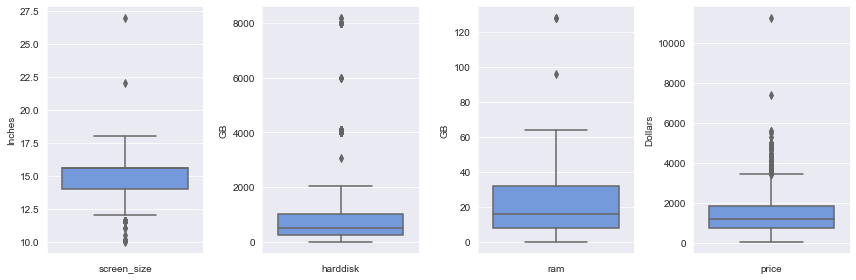

In [42]:
#Plot numerical data to check for outliers
sb.set_style("darkgrid", {"grid.color": "white"})
f, axs = plt.subplots(1, 4, figsize=(12,4))

yLabels = ['Inches', 'GB', 'GB', 'Dollars']
for i in range(4):   
    sb.boxplot(data=df, y=features_num[i], ax=axs[i], color='cornflowerblue')
    axs[i].set(xlabel=features_num[i], ylabel=yLabels[i])
f.tight_layout()

In [43]:
#Check the distance of the price outliers
IQR = df['price'].quantile(0.75) - df['price'].quantile(0.25)
df['price'].quantile(0.75) + (IQR * 5)

7181.7699999999995

In [44]:
#Create a potential alternative to the price column without the outliers
newprice = df['price'].copy()
newprice.loc[df['price'] > df['price'].quantile(0.75) + (IQR * 5)] = np.nan

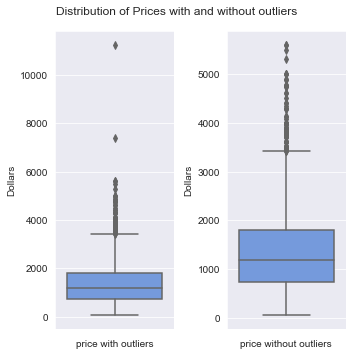

In [45]:
#Plot and compare the price column with and without outliers
f, axs = plt.subplots(1, 2, figsize=(5,5))
   
sb.boxplot(data=df, y='price', ax=axs[0], color='cornflowerblue')
axs[0].set(xlabel='price with outliers', ylabel='Dollars')

sb.boxplot(y=newprice, ax=axs[1], color='cornflowerblue')
axs[1].set(xlabel='price without outliers', ylabel='Dollars')

f.suptitle('Distribution of Prices with and without outliers')
f.tight_layout()

In [46]:
#Remove outliers
df['price'] = newprice

In [47]:
df.dtypes

model                    object
screen_size             float64
harddisk                float64
cpu                      object
ram                     float64
OS                       object
graphics                 object
graphics_coprocessor     object
price                   float64
dtype: object

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2628 entries, 0 to 2627
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model                 2628 non-null   object 
 1   screen_size           2600 non-null   float64
 2   harddisk              2445 non-null   float64
 3   cpu                   2628 non-null   object 
 4   ram                   2570 non-null   float64
 5   OS                    2628 non-null   object 
 6   graphics              2628 non-null   object 
 7   graphics_coprocessor  2628 non-null   object 
 8   price                 2621 non-null   float64
dtypes: float64(4), object(5)
memory usage: 184.9+ KB


In [49]:
#Check how many missing values are in screen_size
df['screen_size'].isna().value_counts()

False    2600
True       28
Name: screen_size, dtype: int64

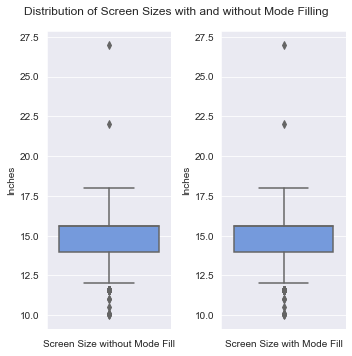

In [50]:
#Plot and compare the impact of mode filling screen_size
fscreen = df['screen_size'].fillna(df['screen_size'].mode()[0])
f, axs = plt.subplots(1, 2, figsize=(5,5))
   
sb.boxplot(data=df, y='screen_size', ax=axs[0], color='cornflowerblue')
axs[0].set(xlabel='Screen Size without Mode Fill', ylabel='Inches')

sb.boxplot(y=fscreen, ax=axs[1], color='cornflowerblue')
axs[1].set(xlabel='Screen Size with Mode Fill', ylabel='Inches')

f.suptitle('Distribution of Screen Sizes with and without Mode Filling')
f.tight_layout()
df['screen_size'] = fscreen

In [51]:
#Check how many missing values are in screen_size
df['ram'].isna().value_counts()

False    2570
True       58
Name: ram, dtype: int64

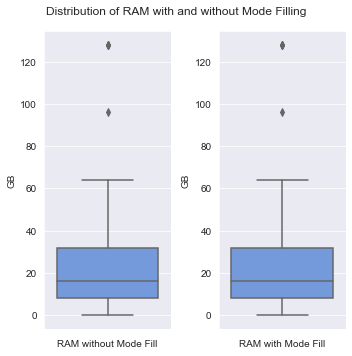

In [52]:
#Plot and compare the impact of mode filling ram
fram = df['ram'].fillna(df['ram'].mode()[0])
f, axs = plt.subplots(1, 2, figsize=(5,5))
   
sb.boxplot(data=df, y='ram', ax=axs[0], color='cornflowerblue')
axs[0].set(xlabel='RAM without Mode Fill', ylabel='GB')

sb.boxplot(y=fram, ax=axs[1], color='cornflowerblue')
axs[1].set(xlabel='RAM with Mode Fill', ylabel='GB')

f.suptitle('Distribution of RAM with and without Mode Filling')
f.tight_layout()
df['ram'] = fram

In [53]:
df['screen_size'].value_counts()

15.60    1050
14.00     640
16.00     216
13.30     186
17.30     144
17.00      83
11.60      79
13.40      43
18.00      39
13.00      35
15.00      24
13.50      11
12.50      10
14.10       8
12.00       7
10.10       7
13.10       6
16.10       5
13.60       4
14.50       4
16.20       4
12.30       3
15.40       3
13.90       3
12.45       2
11.00       2
12.40       2
27.00       1
15.66       1
22.00       1
14.40       1
10.50       1
12.20       1
10.00       1
15.30       1
Name: screen_size, dtype: int64

In [54]:
df['ram'].value_counts()

16.0     1052
32.0      541
8.0       468
64.0      242
4.0       210
12.0       37
24.0       21
40.0       13
48.0       12
20.0       10
2.0         9
1.0         4
6.0         3
128.0       3
0.0         1
5.0         1
96.0        1
Name: ram, dtype: int64

In [55]:
df['harddisk'].value_counts()

512.00     718
256.00     458
1000.00    317
1024.00    310
2000.00    145
2048.00    121
128.00     111
64.00       56
32.00       47
4000.00     44
500.00      32
4096.00     26
8000.00     16
320.00       8
16.00        7
160.00       3
6000.00      3
240.00       2
480.00       2
8192.00      2
8.00         2
65.00        1
0.50         1
640.00       1
1152.00      1
1966.08      1
120.00       1
0.12         1
1512.00      1
1536.00      1
250.00       1
0.03         1
0.06         1
1256.00      1
3072.00      1
300.00       1
Name: harddisk, dtype: int64

In [56]:
#A final duplicate removal after cleaning
df.drop_duplicates(inplace=True, ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2615 entries, 0 to 2614
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model                 2615 non-null   object 
 1   screen_size           2615 non-null   float64
 2   harddisk              2432 non-null   float64
 3   cpu                   2615 non-null   object 
 4   ram                   2615 non-null   float64
 5   OS                    2615 non-null   object 
 6   graphics              2615 non-null   object 
 7   graphics_coprocessor  2615 non-null   object 
 8   price                 2608 non-null   float64
dtypes: float64(4), object(5)
memory usage: 184.0+ KB


In [57]:
#Write the cleaned data to a new file
df.to_excel('amazon_laptop_2023_cleaned.xlsx')

# Problem 2 - Data Analysis

In [58]:
#Calculate the correlation between numerical data
df.corr()['price'][:-1]

screen_size    0.449421
harddisk       0.408086
ram            0.571000
Name: price, dtype: float64

[Text(0.5, 1.0, 'Correlation Between Quality in Components')]

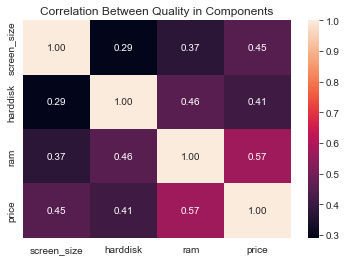

In [59]:
#Plot the correlation
sb.heatmap(df.corr(), annot=True, fmt='.2f').set(title='Correlation Between Quality in Components')

In [60]:
#Restrict laptops to under $1500
df_b = df.loc[df['price'] <= 1500]
df_b

,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
0,hp elitebook 840,14.0,256.0,core i5,16.0,windows 10 pro,integrated,NA,1000.00
1,dell inspiron 15 3530,15.6,2048.0,core i7,64.0,windows 11 home,integrated,iris xe graphics,1000.00
2,dell vostro 3510 laptop,15.6,1000.0,core i7,32.0,windows 10 home,integrated,NA,1000.99
3,dell inspiron 7420 2-in-1,14.0,2000.0,core i5,64.0,windows 11 pro,integrated,intel integrated graphics,1001.11
4,msi prestige 14evo a11mo-217,14.0,NaN,core i7,32.0,windows 10,integrated,iris xe graphics,1001.18
...,...,...,...,...,...,...,...,...,...
2605,hp envy,15.6,512.0,ryzen 7,16.0,windows 11 home,integrated,radeon graphics,999.99
2606,lenovo thinkbook plus,13.3,512.0,core i7,16.0,windows 10 pro,integrated,uhd graphics,999.99
2607,dell xps 13 9300,13.0,256.0,core i7,16.0,windows 10 pro,integrated,NA,999.99
2608,dell latitude 3520 laptop,15.6,2000.0,core i5,16.0,windows 10 home,NA,NA,999.99


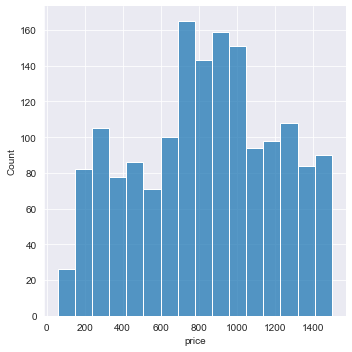

In [61]:
#Plot price distribution
sb.displot(df_b['price'])

In [62]:
#Calculate average price for every laptop for a given component value
means = []

features = ['screen_size', 'ram', 'harddisk']
for i in range(len(features)):
    means.append(df_b[features[i]].value_counts().index.to_series())
    for val in df_b[features[i]].value_counts().index:
        l = df_b['price'].loc[df_b[features[i]] == val]
        means[i].loc[means[i] == val] = l.mean()
means

[15.60     831.963638
 14.00     808.985354
 13.30     921.270455
 16.00    1134.411915
 11.60     308.408481
 17.30     844.913514
 13.00     957.382963
 13.40    1253.689545
 15.00     998.217778
 12.50     480.686000
 17.00    1196.620000
 14.10     208.427500
 13.50     869.493333
 10.10     649.930000
 13.10     454.584000
 12.00     738.225000
 12.30     831.326667
 11.00     218.990000
 13.60    1357.940000
 12.45     399.495000
 13.90     879.905000
 15.40     528.445000
 14.50     794.740000
 10.00     495.000000
 16.10    1409.000000
 12.20     447.950000
 10.50     349.950000
 15.30    1144.480000
 12.40     689.990000
 dtype: float64,
 16.0     988.782492
 8.0      711.381950
 4.0      315.194250
 32.0    1021.162615
 64.0    1018.774848
 12.0     780.976000
 24.0    1135.669333
 20.0     507.964000
 2.0      163.814444
 40.0    1300.662500
 1.0     1097.267500
 48.0    1219.247500
 6.0      411.866667
 5.0     1149.000000
 dtype: float64,
 512.00      969.391701
 256.00   

690.1685156584725
641.4208017753989
1000.0    999.267754
dtype: float64
111
1055.2336936936938


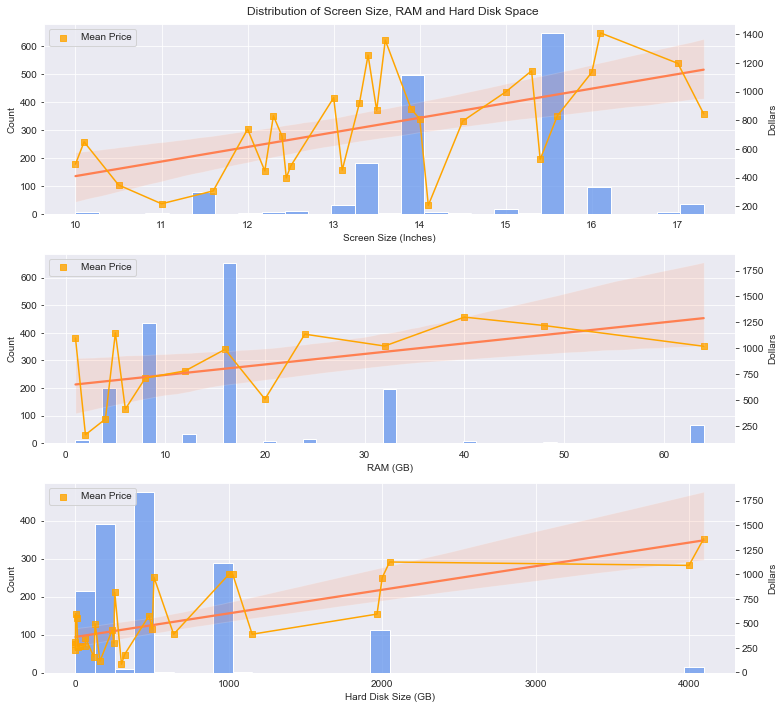

In [64]:
#Plot distribution of screen_size, ram and harddisk and include their average prices with a regression line
f, axs = plt.subplots(3, 1, figsize=(11,10))

#Calculate some specific information
print(means[0].loc[means[0].index <= 14].mean())      
print(means[1].loc[means[1].index <= 8].mean())
print(means[2].loc[means[2].index == 1000])
num = df_b['price'].loc[(df_b['ram'] >= 16) & (df_b['harddisk'] > 1024)].count()
print(num)
print(df_b['price'].loc[(df_b['ram'] >= 16) & (df_b['harddisk'] > 1024)].sum() / num)
    
xLabels = ['Screen Size (Inches)', 'RAM (GB)', 'Hard Disk Size (GB)']
for i in range(len(features)):
    axs[i].set(xlabel=xLabels[i])
    sb.histplot(data=df_b, x=features[i], ax=axs[i], color='cornflowerblue', label='Number of Devices')
    newax = axs[i].twinx()
    newax.set(ylabel='Dollars')
    sb.regplot(x=means[i].index, y=means[i].values, marker='s', color='orange', ax=newax, line_kws=dict(color='coral'), label='Mean Price')
    sb.lineplot(x=means[i].index, y=means[i].values, color='orange', ax=newax)
    newax.grid(False)
    newax.legend(loc=2)
f.suptitle('Distribution of Screen Size, RAM and Hard Disk Space')
f.tight_layout()

              counts    graphics
core i5          623         All
core i7          466         All
celeron          121         All
core i3           89         All
ryzen 7           79         All
other             44         All
ryzen 5           38         All
pentium           20         All
amd a series      16         All
amd r series      14         All
ryzen 3           12         All
core other        10         All
8032              10         All
core i9            4         All
apple              4         All
ryzen 9            2         All
core i5          574  Integrated
core i7          356  Integrated
celeron          118  Integrated
core i3           88  Integrated
ryzen 7           57  Integrated
other             38  Integrated
ryzen 5           34  Integrated
pentium           20  Integrated
amd a series      12  Integrated
ryzen 3           12  Integrated
amd r series      10  Integrated
8032               8  Integrated
core other         8  Integrated
apple     

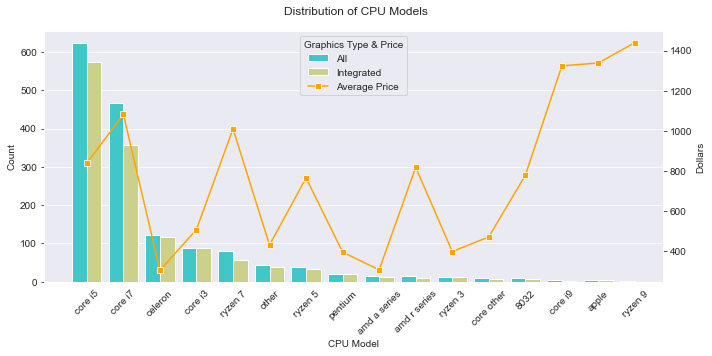

In [69]:
#Plot distribution of cpu and the proportion of the laptops for each cpu that have integrated graphics
cpu = pd.DataFrame()
cpu2 = pd.DataFrame()
cpu['counts'] = df_b['cpu'].value_counts().drop('NA')
cpu['graphics'] = 'All'
cpu2['counts'] = df_b['cpu'].loc[df_b['graphics'] == 'integrated'].value_counts().drop('NA')
cpu2['graphics'] = 'Integrated'
prices = cpu.index.to_series()

#Calculate the average price of a laptop for each cpu
for val in prices.index:
        l = df_b['price'].loc[df_b['cpu'] == val]
        prices[val] = l.mean()

cpu = pd.concat([cpu, cpu2])
print(cpu)
print(prices)

#Calculate the percentage of laptops that have integrated graphics
alltot = cpu['counts'].loc[cpu['graphics'] == 'All'].sum()
inttot = cpu['counts'].loc[cpu['graphics'] == 'Integrated'].sum()
res = float(inttot)/float(alltot)
print(res*100)

fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
sb.barplot(data=cpu, x=cpu.index, y='counts', ax=ax, hue='graphics', palette='rainbow')
sb.lineplot(x=prices.index, y=prices.values, ax=ax2, color='orange', marker='s', label='Average Price', legend=False)


ax2.grid(False)
ax.tick_params(axis='x', labelrotation=45)
ax.set(xlabel='CPU Model', ylabel='Count')
ax2.set(ylabel='Dollars')

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc=0, title='Graphics Type & Price')
fig.suptitle('Distribution of CPU Models')
fig.tight_layout()

In [66]:
df_b.loc[(df_b['screen_size'] < 14) & (df_b['ram'] <= 8) & (df_b['harddisk'] > 950)]

,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
232,dell xps 9300 laptop,13.3,1000.0,core i5,8.0,windows 10 pro,integrated,NA,1199.81
438,asus zenbook s,13.9,1024.0,core i7,1.0,windows 10 pro,integrated,iris xe graphics,1399.90
1915,dell latitude 3330 laptop,13.3,1000.0,core i3,4.0,windows 11 pro,integrated,NA,554.04
2189,dell latitude 5320 2-in-1,13.3,1000.0,core i5,8.0,windows 10 pro,integrated,NA,756.99
2271,dell latitude 5320 laptop,13.3,1000.0,core i5,8.0,windows 10 home,integrated,NA,803.99


In [67]:
df_b.loc[(df_b['screen_size'] > 13) & (df_b['ram'] >= 8) & (df_b['graphics'] != 'integrated') & ((df_b['cpu'] == 'core i9') | (df_b['cpu'] == 'ryzen 9'))]

,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
442,asus vivobook pro 15,15.6,1024.0,ryzen 9,32.0,windows 11 home,dedicated,nvidia geforce rtx 4060,1399.99
444,asus vivobook pro 16,16.0,512.0,core i9,16.0,windows 11 home,dedicated,nvidia geforce rtx 4060,1399.99
502,shoxlab m15r5,15.6,1024.0,ryzen 9,32.0,windows 11,dedicated,nvidia geforce rtx 3070,1479.00
507,asus vivobook pro 16,16.0,1024.0,core i9,16.0,windows 11 home,dedicated,nvidia geforce rtx 4060,1484.99


In [68]:
df_b.loc[(df_b['screen_size'] > 13) & (df_b['ram'] >= 8) & (df_b['graphics'] != 'integrated') & (df_b['cpu'] == 'core i7') & (df_b['graphics_coprocessor'].str.contains('nvidia geforce rtx 4'))]

,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,price
391,msi katana 15,15.6,1024.0,core i7,16.0,windows 11 home,dedicated,nvidia geforce rtx 4070,1349.49
409,dell g15 5530 laptop,15.6,1000.0,core i7,16.0,windows 11 home,dedicated,nvidia geforce rtx 4050,1366.99
430,msi katana 17 b13vfk-835us,17.3,NaN,core i7,32.0,windows 11 home,dedicated,nvidia geforce rtx 4060,1399.00
454,dell g15 5530 laptop,15.6,1000.0,core i7,16.0,windows 11 pro,dedicated,nvidia geforce rtx 4060,1409.99
467,msi katana 15 b13vgk-484us,15.6,1024.0,core i7,16.0,windows 11 home,dedicated,nvidia geforce rtx 4070,1429.00
521,msi pulse 15 b13vfk-1263us,15.6,1024.0,core i7,32.0,windows 11 pro,dedicated,nvidia geforce rtx 4060,1499.00
2489,msi thin gf63 12ve-066us,15.6,512.0,core i7,16.0,windows 11 home,dedicated,nvidia geforce rtx 4050,938.00
